# Loading Libraries and Packages

In [55]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from scipy.linalg import sqrtm
from tqdm import tqdm
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torch.optim as optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np


# Setting the random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    print(f"MPS available. \nUsing MPS as runtime.")
    device = torch.device("mps")
    
elif torch.cuda.is_available():
    print(f"CUDA available. \nUsing CUDA as runtime.")
    device = torch.device("cuda")

else:
    print(f"No GPU available. \nUsing CPU runtime.")
    device = torch.device('cpu')

MPS available. 
Using MPS as runtime.


# Phase 3: Deep Generative Models (PlantVillage & APTOS)

## 3.9 Frechet Inception Distance (FID)

### Dataset and Dataloader

In [2]:
class AptosDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id_code']
        img_path = os.path.join(self.img_dir, img_id + ".png")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.df.iloc[idx]['diagnosis']
        return image, label

In [3]:
root_dir = '../../Assignment 2/aptos2019-blindness-detection'
csv_path = os.path.join(root_dir, "train.csv")
img_dir = os.path.join(root_dir, "train_images")

df = pd.read_csv(csv_path)
df_class4 = df[df['diagnosis'] == 4].reset_index(drop=True)

print("Total Samples (Class 4):", len(df_class4))

train_df, val_df = train_test_split(df_class4,test_size=0.15,random_state=42)
print("Train:", len(train_df))
print("Val:", len(val_df))

Total Samples (Class 4): 295
Train: 250
Val: 45


In [4]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = AptosDataset(train_df, img_dir, transform)
val_dataset = AptosDataset(val_df, img_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

### Model Class

In [61]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            # 1×1 → 4×4
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 4 → 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 → 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1024, 4, 2, 1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  
            nn.Conv2d(1024, 1, 1, 1, 0)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.view(-1)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [63]:
z_dim = 100

G = Generator(z_dim).to(device)
D = Discriminator().to(device)

# Apply weight initialization
G.apply(weights_init)
D.apply(weights_init)

# Use BCEWithLogitsLoss (IMPORTANT)
criterion = nn.BCEWithLogitsLoss()

lr = 2e-4
beta1 = 0.5

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# fake = G(torch.randn(1, z_dim, 1, 1).to(device))
# print("Fake:", fake.shape)

# out = D(fake)
# print("D output:", out.shape)

### Training Loop and Model Loading

In [64]:
save_dir = "../Models"
model_name = "3_9_improved.pth"
model_save_path = os.path.join(save_dir, model_name)

epochs = 15
patience = 5
best_g_loss = float('inf')
counter = 0

for epoch in range(epochs):
    G.train()
    D.train()

    total_d_loss, total_g_loss = 0, 0

    for real, _ in tqdm(train_loader):
        real = real.to(device)
        b = real.size(0)

        # --- Add noise to real images ---
        real = real + 0.05 * torch.randn_like(real)
        real = torch.clamp(real, -1, 1)

        # --- Label smoothing ---
        real_labels = torch.full((b,), 0.9, device=device)
        fake_labels = torch.full((b,), 0.1, device=device)

        # =========================
        # Train Discriminator (2 steps)
        # =========================
        for _ in range(2):
            noise = torch.randn(b, z_dim, 1, 1, device=device)
            fake = G(noise)

            d_real = D(real)
            d_fake = D(fake.detach())

            loss_d = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

            opt_D.zero_grad()
            loss_d.backward()
            opt_D.step()

        # =========================
        # Train Generator
        # =========================
        noise = torch.randn(b, z_dim, 1, 1, device=device)
        fake = G(noise)

        output = D(fake)
        loss_g = criterion(output, real_labels)

        opt_G.zero_grad()
        loss_g.backward()
        opt_G.step()

        total_d_loss += loss_d.item()
        total_g_loss += loss_g.item()

    avg_g_loss = total_g_loss / len(train_loader)

    print(f"Epoch {epoch+1}: D Loss={total_d_loss:.3f}, G Loss={avg_g_loss:.4f}")

    # =========================
    # Early Stopping (based on G loss)
    # =========================
    if avg_g_loss < best_g_loss:
        best_g_loss = avg_g_loss
        torch.save(G.state_dict(), model_save_path)
        counter = 0
        print("Saved Best Model")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

 60%|████████████████████████▋                | 358/594 [14:34<09:36,  2.44s/it]


KeyboardInterrupt: 

In [19]:
# Load Best Model and set for evaluation
G.load_state_dict(torch.load(model_save_path))
G.eval()
print("Model Loaded Successfully")

Model Loaded Successfully


### Inception Net

In [20]:
inception = models.inception_v3(pretrained=True, transform_input=False)
inception.fc = nn.Identity()
inception = inception.to(device)
inception.eval()

resize = transforms.Resize((299, 299))

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/arjunmallick/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|████████████████████████████████████████| 104M/104M [00:04<00:00, 26.0MB/s]


### Feature Extraction and Image Generation

In [21]:
def get_features(loader, model, max_samples=500):
    features = []

    with torch.no_grad():
        for imgs, _ in loader:
            imgs = resize(imgs).to(device)
            feats = model(imgs)
            features.append(feats.cpu().numpy())

            if len(features) * imgs.size(0) >= max_samples:
                break

    return np.concatenate(features, axis=0)[:max_samples]

def generate_fake_images(G, n=500):
    fake_images = []

    with torch.no_grad():
        for _ in range(n // 100):
            noise = torch.randn(100, z_dim, 1, 1, device=device)
            fake = G(noise)
            fake_images.append(fake.cpu())

    return torch.cat(fake_images)

### FID Metrics

In [22]:
def calculate_fid(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

### Driver Code

In [23]:
# Real features
real_features = get_features(val_loader, inception, 500)

# Fake features
fake_imgs = generate_fake_images(G, 500)
fake_loader = DataLoader(list(zip(fake_imgs, [0]*len(fake_imgs))), batch_size=64)
fake_features = get_features(fake_loader, inception, 500)

# Compute statistics
mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
mu_fake, sigma_fake = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

fid_score = calculate_fid(mu_real, sigma_real, mu_fake, sigma_fake)

print("FID Score:", fid_score)

FID Score: 436.32845157594807


## 3.10 Batch Normalization & Mode Collapse

### Model Class

In [26]:
class Generator_NoBN(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [28]:
D = Discriminator().to(device)
G = Generator_NoBN().to(device)

z_dim = 100

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [29]:
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

In [30]:
epochs = 50

for epoch in range(epochs):
    G.train()
    D.train()

    for real, _ in tqdm(train_loader):
        real = real.to(device)
        b = real.size(0)

        real_labels = torch.ones(b, device=device)
        fake_labels = torch.zeros(b, device=device)

        # --- Train Discriminator ---
        noise = torch.randn(b, z_dim, 1, 1, device=device)
        fake = G(noise)

        d_real = D(real)
        d_fake = D(fake.detach())

        loss_d = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        opt_D.zero_grad()
        loss_d.backward()
        opt_D.step()

        # --- Train Generator ---
        output = D(fake)
        loss_g = criterion(output, real_labels)

        opt_G.zero_grad()
        loss_g.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} | D Loss: {loss_d.item():.4f} | G Loss: {loss_g.item():.4f}")

    # Save samples every 5 epochs
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            fake = G(fixed_noise).detach().cpu()
            save_image(fake, f"samples_noBN_epoch_{epoch+1}.png", normalize=True)

100%|█████████████████████████████████████████████| 2/2 [00:14<00:00,  7.30s/it]


Epoch 1 | D Loss: 0.0021 | G Loss: 13.7221


100%|█████████████████████████████████████████████| 2/2 [00:15<00:00,  7.57s/it]


Epoch 2 | D Loss: 0.0002 | G Loss: 13.4311


100%|█████████████████████████████████████████████| 2/2 [00:14<00:00,  7.22s/it]


...

Epoch 48 | D Loss: 0.0009 | G Loss: 9.6392


100%|█████████████████████████████████████████████| 2/2 [00:14<00:00,  7.11s/it]


Epoch 49 | D Loss: 0.0003 | G Loss: 10.9659


100%|█████████████████████████████████████████████| 2/2 [00:14<00:00,  7.09s/it]


Epoch 50 | D Loss: 0.0007 | G Loss: 9.9871


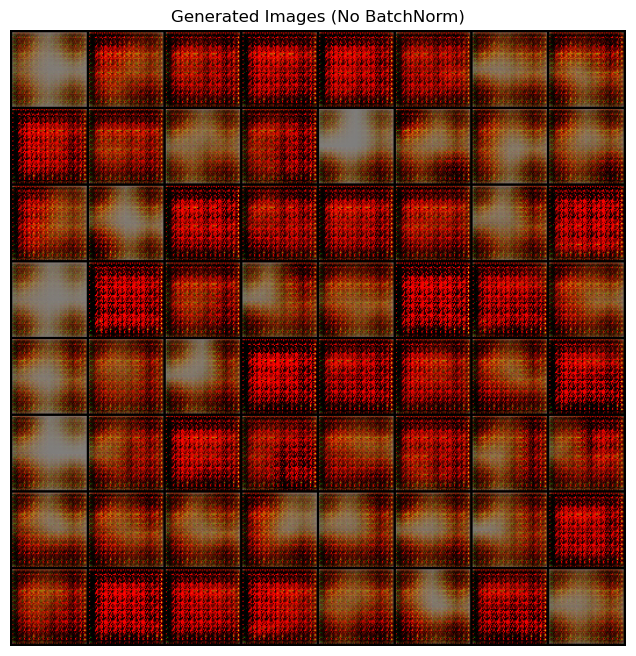

In [57]:
with torch.no_grad():
    fake = G(fixed_noise).cpu()

grid = make_grid(fake, nrow=8, normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Generated Images (No BatchNorm)")
plt.savefig("../Report/3.10.png", dpi = 300)
plt.show()

## 3.7 ELBO Implementation

### Dataset Loading and Splitting

In [38]:
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset_path = '../../Assignment 2/plantvillage dataset/segmented'

# Load the dataset
image_dataset = datasets.ImageFolder(root=dataset_path, transform=data_transforms)

print(f"Total images found: {len(image_dataset)}")

targets = image_dataset.targets
indices = np.arange(len(targets))

# Split 70% Train, 30% Temp
train_idx, temp_idx, train_targets, temp_targets = train_test_split(
    indices, 
    targets, 
    test_size=0.30,
    stratify=targets, 
    random_state=42 
)

# Split Temp into 15% Val, 15% Test
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.50,
    stratify=temp_targets, 
    random_state=42
)

train_dataset = Subset(image_dataset, train_idx)
val_dataset = Subset(image_dataset, val_idx)
test_dataset = Subset(image_dataset, test_idx)

print(f"Training Set:   {len(train_dataset)} images (70%)")
print(f"Validation Set: {len(val_dataset)} images (15%)")
print(f"Testing Set:    {len(test_dataset)} images (15%)")

BATCH_SIZE = 64  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Total images found: 54306
Training Set:   38014 images (70%)
Validation Set: 8146 images (15%)
Testing Set:    8146 images (15%)


### Convolutional VAE Architecture

In [33]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(ConvVAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # 32 x 64 x 64
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 32 x 32
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 16 x 16
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 256 x 8 x 8
            nn.BatchNorm2d(256), nn.ReLU(),
        )
        
        self.flatten_size = 256 * 8 * 8
        
        # Latent Space (mu and log_var)
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        
        # Decoder Input
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 128 x 16 x 16
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 64 x 32 x 32
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 32 x 64 x 64
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1), # 3 x 128 x 128
            nn.Sigmoid() # Scale outputs to [0, 1] for images
        )

    def encode(self, x):
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 256, 8, 8) # Unflatten
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

### Loss Function (Negative ELBO)

In [35]:
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE) - sum over all elements, mean over batch later
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    
    # KL Divergence term
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss, kl_divergence

### Training Loop

In [40]:
save_dir = "../Models"
model_name = "3_7_Conv_VAE.pth"
model_save_path = os.path.join(save_dir, model_name)

print(f"Training on device: {device}")

vae_model = ConvVAE(latent_dim=128).to(device)
optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

EPOCHS = 15
PATIENCE = 3   # early stopping patience

# Tracking
history_recon_loss = []
history_kl_loss = []

best_loss = float('inf')
early_stop_counter = 0

for epoch in range(EPOCHS):
    vae_model.train()
    
    train_recon = 0.0
    train_kl = 0.0
    
    for images, _ in train_loader:
        images = images.to(device)
        
        optimizer.zero_grad()
        
        recon_images, mu, logvar = vae_model(images)
        
        recon_loss, kl_loss = vae_loss_function(recon_images, images, mu, logvar)
        loss = recon_loss + kl_loss
        
        loss.backward()
        optimizer.step()
        
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()
    
    # --- Average losses ---
    avg_recon = train_recon / len(train_loader.dataset)
    avg_kl = train_kl / len(train_loader.dataset)
    total_loss = avg_recon + avg_kl

    history_recon_loss.append(avg_recon)
    history_kl_loss.append(avg_kl)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"| Recon: {avg_recon:.4f} | KL: {avg_kl:.4f} | Total: {total_loss:.4f}")

    # --- Model Checkpoint ---
    if total_loss < best_loss:
        best_loss = total_loss
        early_stop_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': vae_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss
        }, model_save_path)

        print("✔ Best model saved")

    else:
        early_stop_counter += 1

    # --- Early Stopping ---
    if early_stop_counter >= PATIENCE:
        print("Early stopping triggered")
        break

Training on device: mps
Epoch [1/15] | Recon: 709.6433 | KL: 126.1450 | Total: 835.7884
✔ Best model saved
Epoch [2/15] | Recon: 353.8544 | KL: 97.0160 | Total: 450.8704
✔ Best model saved
Epoch [3/15] | Recon: 306.5630 | KL: 96.6778 | Total: 403.2408
✔ Best model saved
Epoch [4/15] | Recon: 287.4415 | KL: 97.5179 | Total: 384.9594
✔ Best model saved
Epoch [5/15] | Recon: 277.5508 | KL: 98.4943 | Total: 376.0451
✔ Best model saved
Epoch [6/15] | Recon: 268.7908 | KL: 98.8510 | Total: 367.6418
✔ Best model saved
Epoch [7/15] | Recon: 260.6920 | KL: 99.1452 | Total: 359.8373
✔ Best model saved
Epoch [8/15] | Recon: 257.5342 | KL: 99.5843 | Total: 357.1185
✔ Best model saved
Epoch [9/15] | Recon: 251.5224 | KL: 100.0854 | Total: 351.6078
✔ Best model saved
Epoch [10/15] | Recon: 249.3281 | KL: 100.3592 | Total: 349.6873
✔ Best model saved
Epoch [11/15] | Recon: 246.8135 | KL: 100.4752 | Total: 347.2886
✔ Best model saved
Epoch [12/15] | Recon: 244.0820 | KL: 100.7932 | Total: 344.8752
✔ B

### Visualization

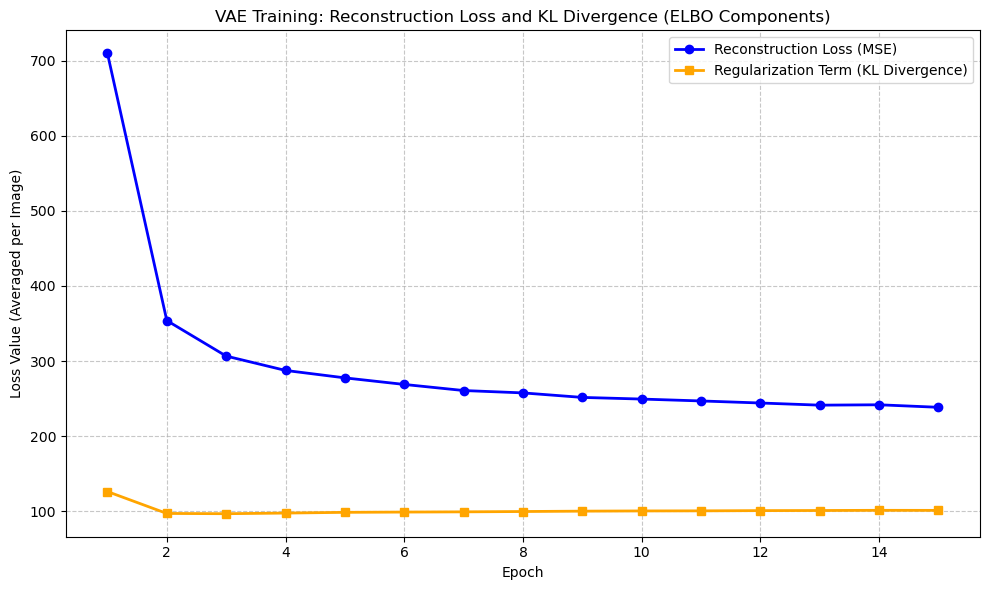

In [50]:
img_save_path = "../Report/3_7.png"
plt.figure(figsize=(10, 6))
epochs_range = range(1, EPOCHS + 1)

plt.plot(epochs_range, history_recon_loss, label='Reconstruction Loss (MSE)', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, history_kl_loss, label='Regularization Term (KL Divergence)', color='orange', linewidth=2, marker='s')

plt.title('VAE Training: Reconstruction Loss and KL Divergence (ELBO Components)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value (Averaged per Image)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(img_save_path,dpi = 300)
plt.show()

## 3.8 VAE vs. Simple DCGAN

### Model Class

In [47]:
# Use the same transformations and DataLoader setup from your previous code:
# Assume image_dataset (datasets.ImageFolder) and train_loader are already defined.
# BATCH_SIZE = 64
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100 # Standard for DCGAN

# ==========================================
# DCGAN Generator Model
# ==========================================
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Project noise to the first feature map dimension (128x128 output size)
        self.main = nn.Sequential(
            # Input is (latent_dim) x 1 x 1
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False), # (512, 4, 4)
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), # (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), # (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False), # (32, 64, 64)
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # Final layer maps to 3 channels (RGB) 128x128
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False), # (3, 128, 128)
            nn.Tanh() # Output range [-1, 1] for images
        )

    def forward(self, x):
        return self.main(x)

# ==========================================
# DCGAN Discriminator Model
# ==========================================
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # Discriminator takes image (3x128x128) and outputs a probability [0, 1]
        self.main = nn.Sequential(
            # Input is (3, 128, 128)
            nn.Conv2d(3, 32, 4, 2, 1, bias=False), # (32, 64, 64)
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, 4, 2, 1, bias=False), # (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), # (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), # (512, 4, 4)
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # Output is a single value probability
            nn.Conv2d(512, 1, 4, 1, 0, bias=False), # (1, 1, 1)
            nn.Sigmoid() # Range [0, 1]
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

In [48]:
###### Initialize DCGAN ######
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss and Optimizers
criterion = nn.BCELoss() # Standard GAN Binary Cross Entropy loss
lr = 0.0002 # Standard DCGAN learning rate
optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# Standardize data to [-1, 1] for GANs (using existing transform sequence but scaling)
# ToTensor() gets to [0, 1], now scale by mean/std
image_dataset.transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
])
# Re-initialize DataLoader with updated transform
gan_loader = DataLoader(image_dataset, batch_size=BATCH_SIZE, shuffle=True)

### Training and Evaluation

In [51]:
# DCGAN Training Loop
num_epochs = 25 # Increased for GAN convergence
print(f"Training on device {device}")
print("Starting DCGAN Training Loop...")
for epoch in range(num_epochs):
    # For reporting
    loss_g = 0.0
    loss_d = 0.0
    
    for i, (images, _) in enumerate(gan_loader):
        current_batch_size = images.size(0)
        images = images.to(device)
        
        # Define adversarial labels (real=1, fake=0)
        real_labels = torch.ones(current_batch_size).to(device)
        fake_labels = torch.zeros(current_batch_size).to(device)

        # Train Discriminator
        discriminator.zero_grad()
        
        # 1. Train with real images
        output_real = discriminator(images)
        loss_d_real = criterion(output_real, real_labels)
        loss_d_real.backward()
        
        # 2. Train with fake images
        noise = torch.randn(current_batch_size, latent_dim, 1, 1).to(device)
        fake_images = generator(noise)
        output_fake = discriminator(fake_images.detach())
        loss_d_fake = criterion(output_fake, fake_labels)
        loss_d_fake.backward()
        
        # Update Discriminator
        optimizer_d.step()
        
        # Train Generator
        generator.zero_grad()
        
        # We want Generator to create images D(fake) -> 1
        output_fake_g = discriminator(fake_images) # Re-calculate since D was updated
        loss_g_step = criterion(output_fake_g, real_labels) # Use real labels to train G
        loss_g_step.backward()
        
        # Update Generator
        optimizer_g.step()

        loss_g += loss_g_step.item()
        loss_d += (loss_d_real.item() + loss_d_fake.item())

    # if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss_D: {loss_d / len(gan_loader):.4f} | Loss_G: {loss_g / len(gan_loader):.4f}")

Training on device mps
Starting DCGAN Training Loop...
Epoch [1/25] | Loss_D: 0.9169 | Loss_G: 2.6625
Epoch [2/25] | Loss_D: 0.9407 | Loss_G: 2.3750
Epoch [3/25] | Loss_D: 0.8990 | Loss_G: 2.4071
Epoch [4/25] | Loss_D: 0.8549 | Loss_G: 2.5511
Epoch [5/25] | Loss_D: 0.8156 | Loss_G: 2.7217
Epoch [6/25] | Loss_D: 0.7548 | Loss_G: 2.8458
Epoch [7/25] | Loss_D: 0.6800 | Loss_G: 3.1173
Epoch [8/25] | Loss_D: 0.6129 | Loss_G: 3.3119
Epoch [9/25] | Loss_D: 0.5542 | Loss_G: 3.5738
Epoch [10/25] | Loss_D: 0.4957 | Loss_G: 3.8198
Epoch [11/25] | Loss_D: 0.4676 | Loss_G: 4.0155
Epoch [12/25] | Loss_D: 0.4417 | Loss_G: 4.1177
Epoch [13/25] | Loss_D: 0.3869 | Loss_G: 4.3073
Epoch [14/25] | Loss_D: 0.4028 | Loss_G: 4.3063
Epoch [15/25] | Loss_D: 0.3861 | Loss_G: 4.3632
Epoch [16/25] | Loss_D: 0.3237 | Loss_G: 4.6068
Epoch [17/25] | Loss_D: 0.3316 | Loss_G: 4.7836
Epoch [18/25] | Loss_D: 0.3220 | Loss_G: 4.6381
Epoch [19/25] | Loss_D: 0.2953 | Loss_G: 4.9100
Epoch [20/25] | Loss_D: 0.2590 | Loss_G: 5

In [52]:
# Save the models
torch.save(generator.state_dict(), "../Models/3_8_generator.pth")
torch.save(discriminator.state_dict(), "../Models/3_8_discriminator.pth")

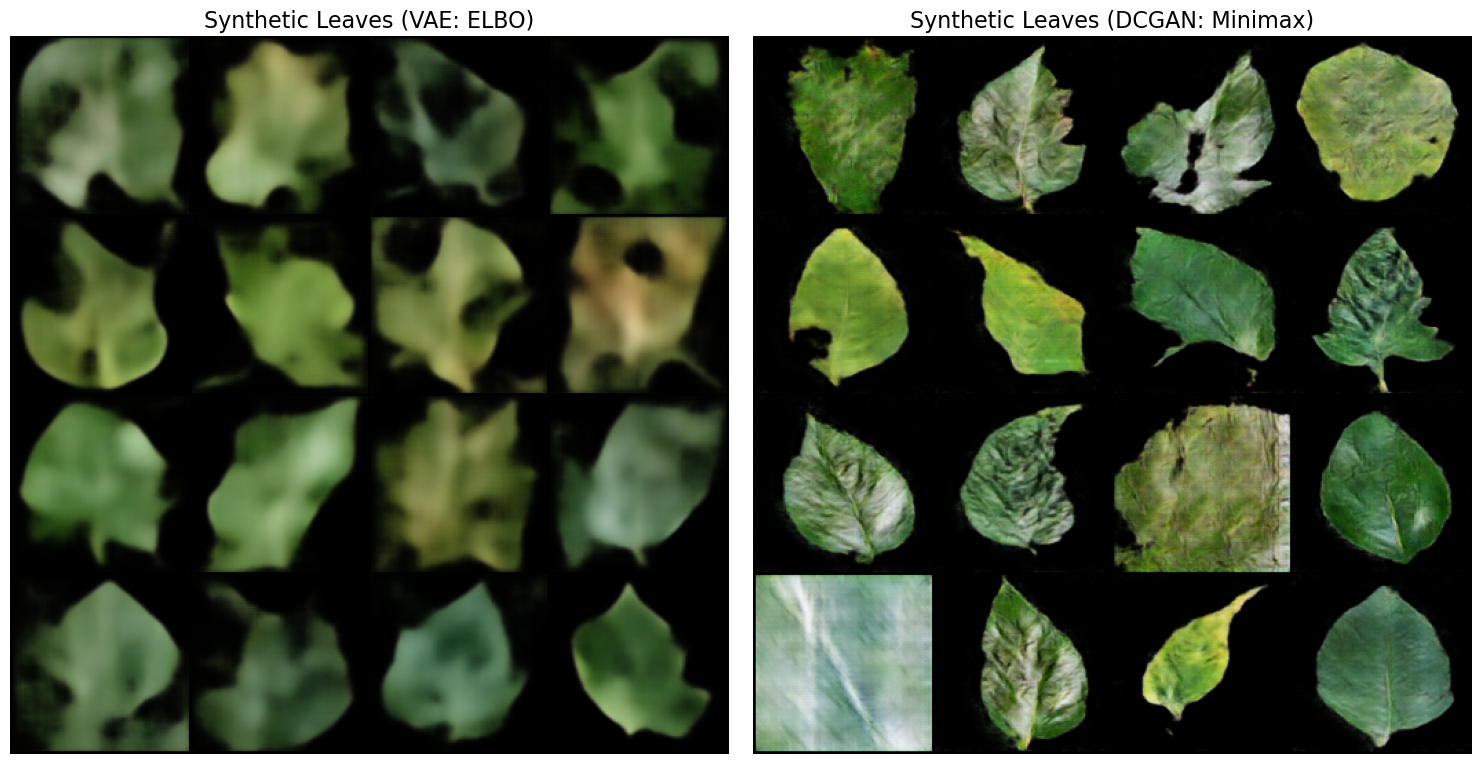

In [54]:
from torchvision import datasets, transforms, utils
# Assuming vae_model is already loaded and trained
# Assume generator is already loaded and trained (DCGAN Generator)
# device is defined as CPU or CUDA

num_synthetic = 16

# ==========================================
# Generate images from VAE
# ==========================================
vae_model.eval()
with torch.no_grad():
    # To generate new images with VAE, we sample from the prior p(z) = N(0, I)
    z_vae = torch.randn(num_synthetic, 128).to(device) # latent_dim=128
    vae_generated_images = vae_model.decode(z_vae).cpu()

# ==========================================
# Generate images from DCGAN
# ==========================================
generator.eval()
with torch.no_grad():
    # GAN takes noise shaped (latent_dim, 1, 1)
    noise_gan = torch.randn(num_synthetic, latent_dim, 1, 1).to(device) # latent_dim=100
    gan_generated_images_normalized = generator(noise_gan).cpu()
    # DCGAN uses Tanh [-1, 1] output. Denormalize to [0, 1] for display.
    gan_generated_images = (gan_generated_images_normalized + 1) / 2.0

# ==========================================
# Plot the results side-by-side
# ==========================================
fig, axs = plt.subplots(1, 2, figsize=(15, 7.5))

# Plot VAE grid
vae_grid = utils.make_grid(vae_generated_images, nrow=4, padding=2, normalize=False)
axs[0].imshow(np.transpose(vae_grid, (1, 2, 0)))
axs[0].axis('off')
axs[0].set_title("Synthetic Leaves (VAE: ELBO)", fontsize=16)
axs[0].set_aspect('equal')

# Plot DCGAN grid
gan_grid = utils.make_grid(gan_generated_images, nrow=4, padding=2, normalize=False)
axs[1].imshow(np.transpose(gan_grid, (1, 2, 0)))
axs[1].axis('off')
axs[1].set_title("Synthetic Leaves (DCGAN: Minimax)", fontsize=16)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.savefig("../Report/3_8.png", dpi = 300)
plt.show()